<a href="https://colab.research.google.com/github/tanishqsayil-lab/MLEL--Experiment/blob/main/assign10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

In [2]:
data = fetch_california_housing()

X = data.data
y = data.target

print("Samples:", X.shape[0])
print("Features:", X.shape[1])

print(pd.DataFrame(X, columns=data.feature_names).head())

Samples: 20640
Features: 8
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (16512, 8)
Testing Shape: (4128, 8)


In [4]:
def cost_function(X, y, w):
    m = len(y)
    pred = X.dot(w)
    return np.sum((pred - y) ** 2) / (2 * m)

In [5]:
def batch_gd(X, y, lr=0.01, iters=100):
    m, n = X.shape
    w = np.zeros(n)
    costs = []

    for i in range(iters):
        pred = X.dot(w)
        grad = (1/m) * X.T.dot(pred - y)
        w = w - lr * grad
        costs.append(cost_function(X, y, w))

    return w, costs

w1, cost1 = batch_gd(X_train, y_train)

In [6]:
def stochastic_gd(X, y, lr=0.01, iters=100):
    m, n = X.shape
    w = np.zeros(n)
    costs = []

    for j in range(iters):
        for i in range(m):
            xi = X[i]
            yi = y[i]
            pred = xi.dot(w)
            grad = xi * (pred - yi)
            w = w - lr * grad

        costs.append(cost_function(X, y, w))

    return w, costs

w2, cost2 = stochastic_gd(X_train, y_train)

/tmp/ipykernel_3752/272355368.py:4: RuntimeWarning: overflow encountered in square
  return np.sum((pred - y) ** 2) / (2 * m)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/tmp/ipykernel_3752/3961617216.py:11: RuntimeWarning: overflow encountered in multiply
  grad = xi * (pred - yi)
/tmp/ipykernel_3752/3961617216.py:12: RuntimeWarning: invalid value encountered in subtract
  w = w - lr * grad


In [7]:
def mini_batch_gd(X, y, lr=0.01, iters=100, batch=32):
    m, n = X.shape
    w = np.zeros(n)
    costs = []

    for j in range(iters):
        for i in range(0, m, batch):
            Xb = X[i:i+batch]
            yb = y[i:i+batch]

            pred = Xb.dot(w)
            grad = (1/len(yb)) * Xb.T.dot(pred - yb)
            w = w - lr * grad

        costs.append(cost_function(X, y, w))

    return w, costs

w3, cost3 = mini_batch_gd(X_train, y_train)

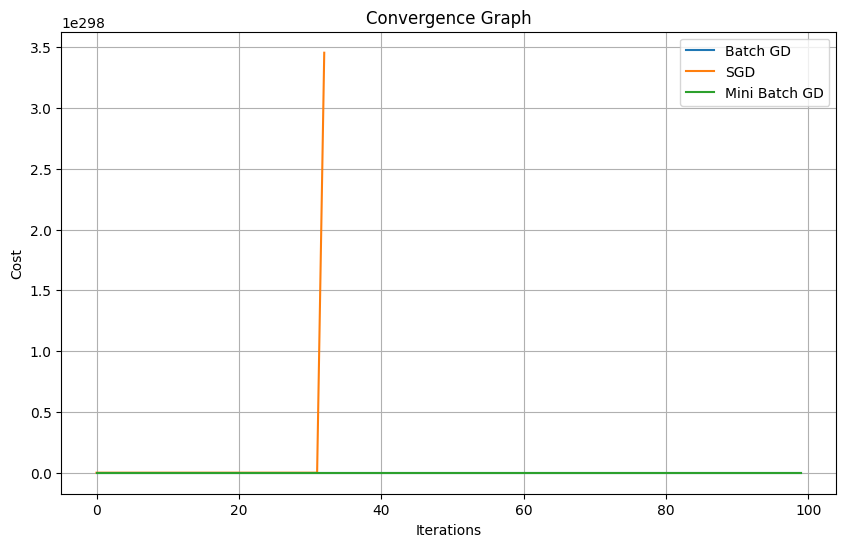

In [8]:
plt.figure(figsize=(10,6))
plt.plot(cost1, label="Batch GD")
plt.plot(cost2, label="SGD")
plt.plot(cost3, label="Mini Batch GD")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Convergence Graph")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
pred1 = X_test.dot(w1)
pred2 = X_test.dot(w2)
pred3 = X_test.dot(w3)

rmse1 = np.sqrt(mean_squared_error(y_test, pred1))
rmse2 = np.sqrt(mean_squared_error(y_test, pred2))
rmse3 = np.sqrt(mean_squared_error(y_test, pred3))

print("Batch GD RMSE:", rmse1)
print("SGD RMSE:", rmse2)
print("Mini Batch GD RMSE:", rmse3)

ValueError: Input contains NaN.

In [10]:
print("SGD is useful for large data and faster learning.")
print("Batch GD is stable but slow.")
print("Mini Batch GD is mostly preferred in practice.")
print("Learning rate controls speed of convergence.")

SGD is useful for large data and faster learning.
Batch GD is stable but slow.
Mini Batch GD is mostly preferred in practice.
Learning rate controls speed of convergence.
